In [1]:
# ==========================================================
#                   Universidad Franz Tamayo
# ----------------------------------------------------------
#                        MINERIA DE DATOS
# ----------------------------------------------------------
#        Enrique Alejandro Laurel Cossio, Abr 2026
# ==========================================================
#  Árboles de Decisión para problemas clasificación
# ==========================================================

# 1. LIBRERIAS Y FUNCIONES

In [2]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# modelos lineales
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# indicadores de ajuste del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# modelos de árboles de decisión
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

# ÁRBOLES DE DECISIÓN - CLASIFICACIÓN

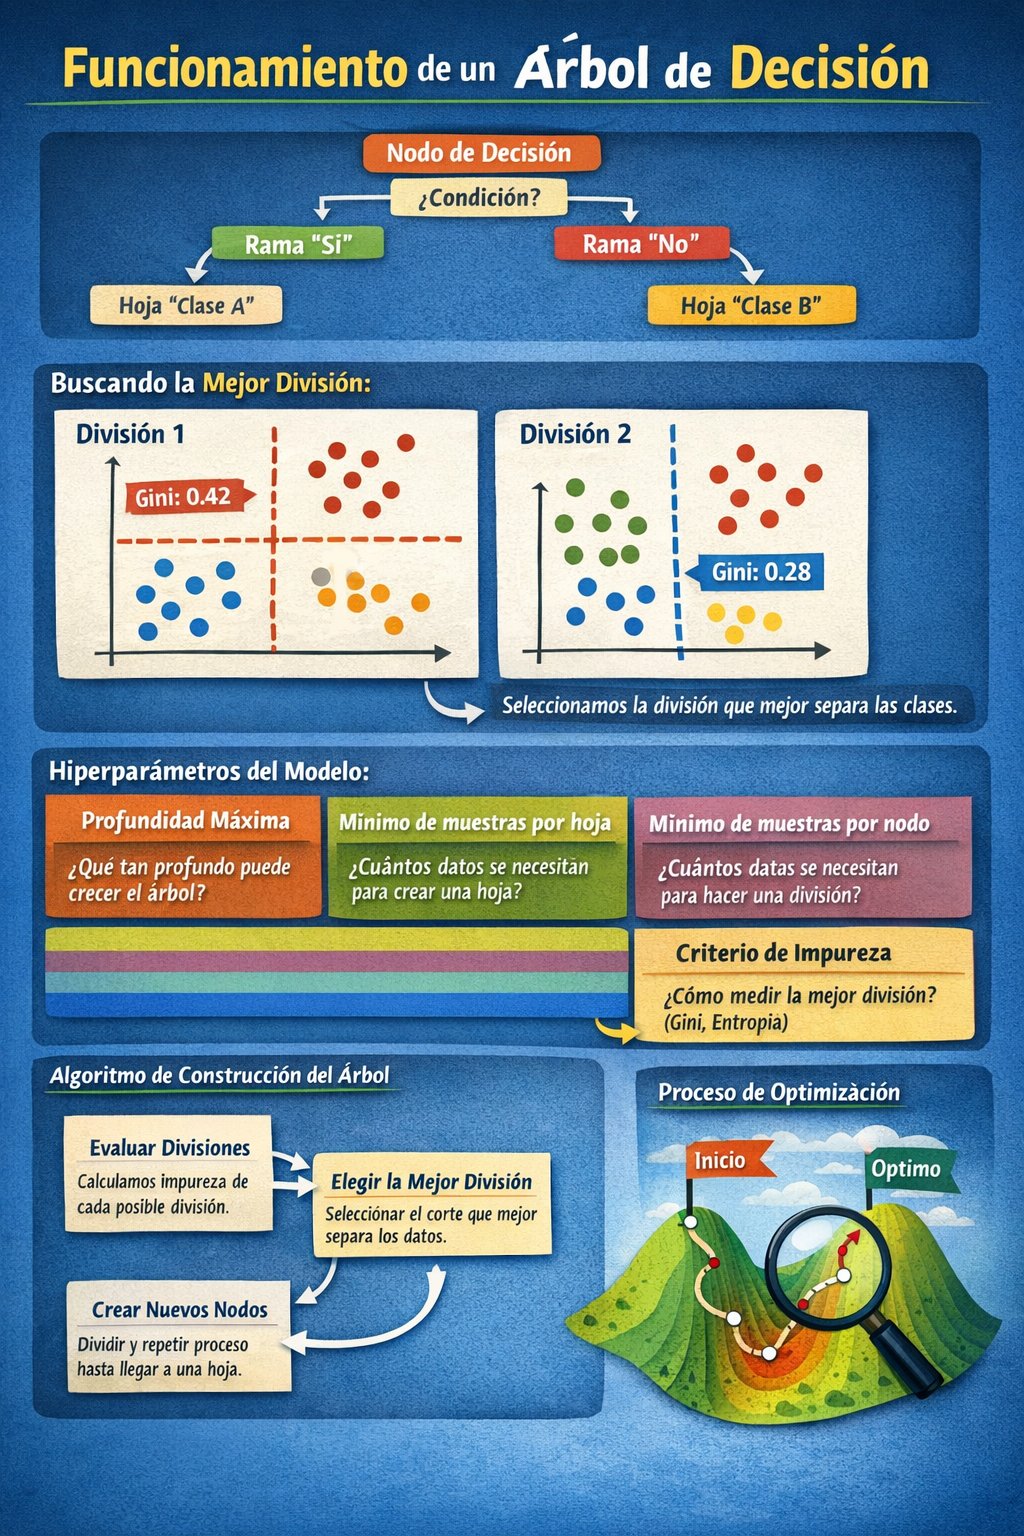

**Idea y Objetivo**
Idea principal: dividir el espacio de datos en regiones homogéneas mediante reglas tipo “si-entonces”.

Objetivo: clasificar observaciones en categorías (ej. “aprobado” vs “reprobado”, “fraudulento” vs “legítimo”).

**Principales Elementos**

Nodo raíz: punto inicial donde se evalúa la primera condición.

Nodos de decisión: preguntas intermedias que dividen los datos.

Ramas: caminos que siguen las respuestas.

Hojas: resultados finales (clases asignadas).

✅ **Ventajas**

Fácil de interpretar y explicar.

No requiere supuestos de linealidad.

Maneja variables categóricas y numéricas.

Puede capturar interacciones complejas.

❌ **Desventajas**

Propenso al sobreajuste si no se controla.

Menor precisión comparado con modelos más avanzados (ej. Random Forest, XGBoost).

Inestable: pequeños cambios en datos pueden alterar la estructura.

# 3. DATOS

In [28]:
# cargamos datos

ifood_df = pd.read_csv('data/ifood.csv',sep=',', encoding='iso-8859-1')

print(ifood_df.shape) #
ifood_df.head(2)

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0


In [29]:
ifood_df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [30]:
ifood_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [31]:
# una copia a los datos
df = ifood_df.copy()

In [32]:
# convertir a dummies las variables categoricas o cualitativas
df = pd.get_dummies(df, columns=['Education','Marital_Status'], drop_first=True)
print(df.shape)
df.head(2)

(2240, 38)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,True,False,False,False,False,False,True,False,False,False
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,True,False,False,False,False,False,True,False,False,False


In [33]:
## convertir las variables booleanas a enteros
#df = df.replace({True: 1, False: 0})
#df.head(2)

# Convertimos a entero todos los campos que empiezan con 'Education' o 'Marital_Status'
for col in df.columns:
    if col.startswith('Education') or col.startswith('Marital_Status'):
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)
df[[c for c in df.columns if c.startswith('Education') or c.startswith('Marital_Status')]].head(2)

print(df.shape)
df.head(2)

(2240, 38)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,1,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,1,0,0,0,0,0,1,0,0,0


In [9]:
# Aqui hay todo un proceso de exploración y limpieza de datos
# que no se muestra en este notebook

In [34]:
df.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='str')

In [38]:
df[['Kidhome','Recency','Education_Basic','Response']].dtypes

Kidhome            int64
Recency            int64
Education_Basic    int64
Response           int64
dtype: object

In [39]:
# seleccionamos variables explicativas y variables dependiente
#X = df[['Kidhome','Recency','education_Basic','Complain','Income','MntTotal','Age']]
X = df[['Kidhome','Recency','Education_Basic']] # variables independientes
y = df['Response'] # variable dependiente o variable a predecir o variable objetivo

In [40]:
y.head(2)

0    1
1    0
Name: Response, dtype: int64

In [41]:
# Dividir los datos en conjuntos de entrenamiento y prueba o testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [42]:
# hallamos los mejores hiperparametros del modelo de árbol de decisión
# Crear el clasificador
clf = DecisionTreeClassifier()

# Definir la grilla de hiperparámetros a explorar
param_grid = {
    'max_depth': list(range(1,20)),#[1, 2,3,4,5,6,7,8,9,10,15, 20],
    'min_samples_split': list(range(1,10)),
    'min_samples_leaf': list(range(1,4))
}

# Realizar búsqueda en la grilla
grid_search = GridSearchCV(clf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Mejores hiperparámetros encontrados
best_params = grid_search.best_params_
best_params

c:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
285 fits failed out of a total of 2565.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
285 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ENRIQUE\miniconda3\envs\mineria_datos\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\ENRIQUE\minicond

{'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [43]:
# Entrenamos el Modelo de Árbol de Decisión para Clasificación

# Crea un clasificador de árbol de decisión
modelo_ArbolDecisionClasif = DecisionTreeClassifier(max_depth=1,min_samples_leaf=1,min_samples_split=2)

# Entrena el modelo en los datos de entrenamiento
modelo_ArbolDecisionClasif.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

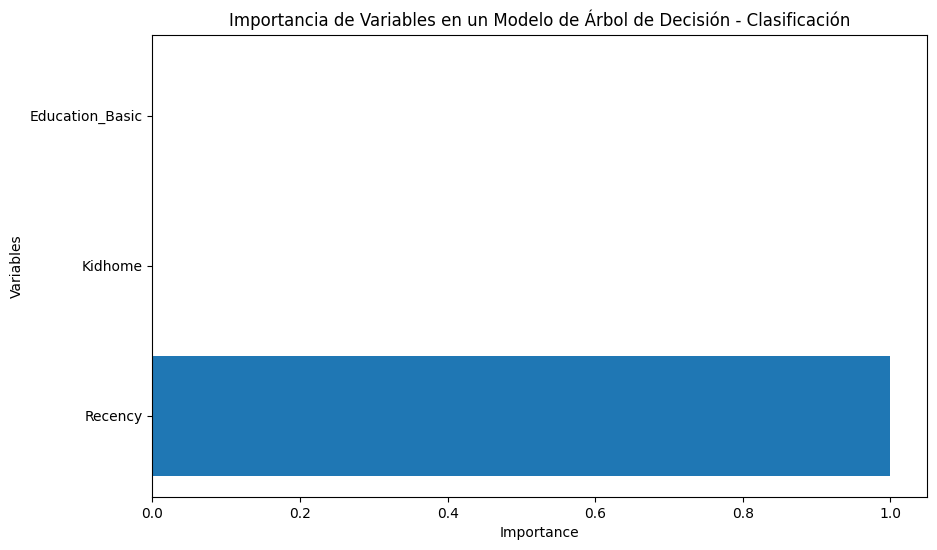

In [44]:
# Obtenemos la importancia de las variables
feature_importance = modelo_ArbolDecisionClasif.feature_importances_

# Creamos un DataFrame para visualizar las importancias junto con los nombres de las variables
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Ordenamos por importancia descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Importancia de Variables en un Modelo de Árbol de Decisión - Clasificación')
plt.show()

In [45]:
y_train.value_counts()

Response
0    1526
1     266
Name: count, dtype: int64

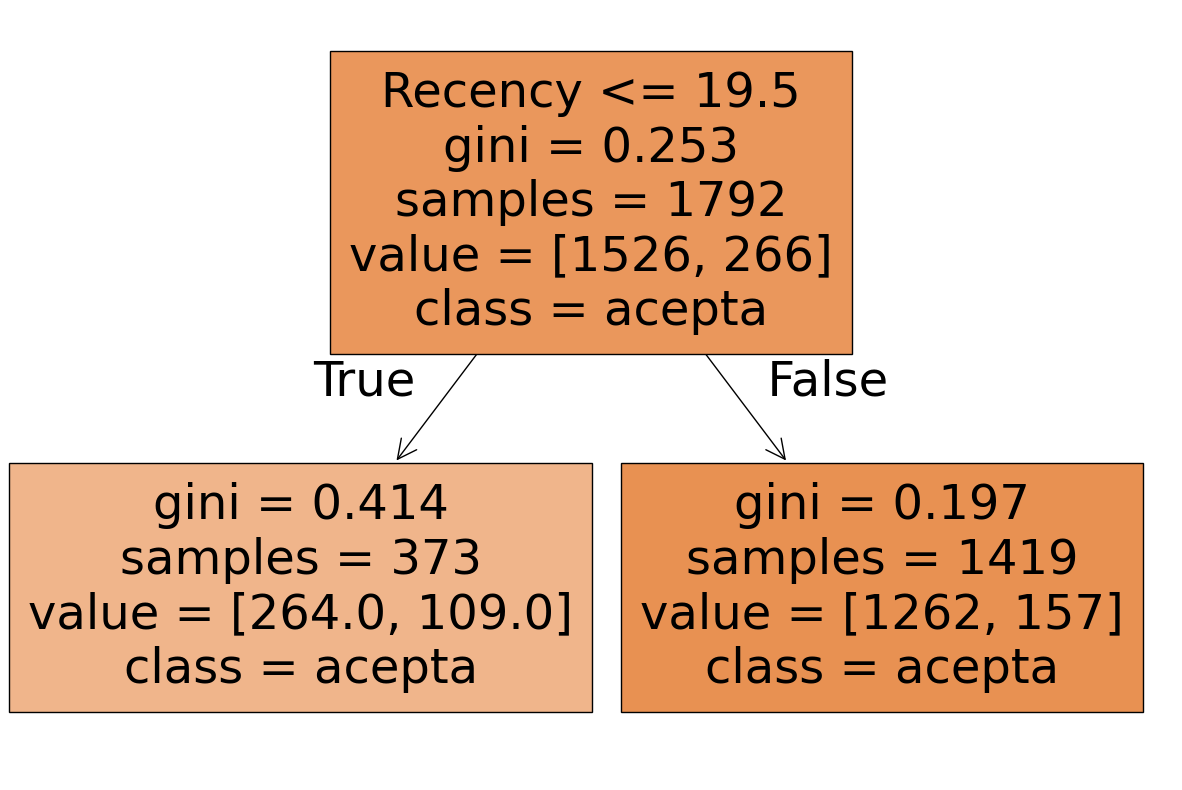

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(modelo_ArbolDecisionClasif, filled=True, feature_names=X_train.columns, class_names=['acepta', 'no acepta'])
plt.show()

In [47]:
# poner una semilla para reproducibilidad del modelo
np.random.seed(42)

In [48]:
X_train.head(2)

,Kidhome,Recency,Education_Basic
351,1,93,0
1640,1,56,0


In [49]:
y_train.dtypes

dtype('int64')

In [ ]:
# Ajusta el modelo de regresión logística
modelo_logit = sm.Logit(y_train, X_train).fit()

In [70]:
# Muestra un resumen del modelo
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 1792
Model:                          Logit   Df Residuals:                     1789
Method:                           MLE   Df Model:                            2
Date:                Wed, 15 Oct 2025   Pseudo R-squ.:                 0.04250
Time:                        20:17:12   Log-Likelihood:                -720.63
converged:                       True   LL-Null:                       -752.62
Covariance Type:            nonrobust   LLR p-value:                 1.282e-14
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Kidhome            -0.7642      0.125     -6.108      0.000      -1.009      -0.519
Recency            -0.0306      0.002    -17.949      0.000      -0.034      -0.027
Education_Basic    -2.0721      

In [50]:
X_test

,Kidhome,Recency,Education_Basic
585,1,10,0
549,1,33,0
619,0,6,0
77,0,40,0
1875,0,3,0
...,...,...,...
147,1,49,0
40,0,3,0
1228,0,64,0
1988,1,39,0


In [51]:
# ajustamos el indice en x_test
X_test.reset_index(drop=True, inplace=True)


In [52]:
X_test

,Kidhome,Recency,Education_Basic
0,1,10,0
1,1,33,0
2,0,6,0
3,0,40,0
4,0,3,0
...,...,...,...
443,1,49,0
444,0,3,0
445,0,64,0
446,1,39,0


In [75]:
# Realiza predicciones en el conjunto de datos de prueba

# Regresión Logistica - Logit
print('Predicción Regresión Logística - Logit')
y_pred_logit = modelo_logit.predict(X_test)
print(y_pred_logit.head(2))

# Arbol de Decisión - Clasificación
print('Predicción Árbol de Decisión - Clasificación')
y_pred_ArbolDecisionClasif = modelo_ArbolDecisionClasif.predict_proba(X_test)
y_pred_ArbolDecisionClasif = pd.DataFrame(y_pred_ArbolDecisionClasif)
y_pred_ArbolDecisionClasif = y_pred_ArbolDecisionClasif.iloc[:,1]
print(y_pred_ArbolDecisionClasif.head(2))

Predicción Regresión Logística - Logit
0    0.255441
1    0.145214
dtype: float64
Predicción Árbol de Decisión - Clasificación
0    0.292225
1    0.110641
Name: 1, dtype: float64


In [76]:
# Obteniendo el mejor corte de predicción
# Calcular la curva ROC - LOGIT
fpr, tpr, thresholds = roc_curve(y_test, y_pred_logit)

# Encontrar el umbral óptimo (máximo índice de Youden)
youden_index = tpr - fpr
optimal_threshold_logit = thresholds[np.argmax(youden_index)]

print("Umbral óptimo Logit:", optimal_threshold_logit)

Umbral óptimo Logit: 0.17829925270300853


In [77]:
# Obteniendo el mejor corte de predicción
# Calcular la curva ROC - Arbol de Decisión
fpr, tpr, thresholds = roc_curve(y_test, y_pred_ArbolDecisionClasif)

# Encontrar el umbral óptimo (máximo índice de Youden)
youden_index = tpr - fpr
optimal_threshold_tree = thresholds[np.argmax(youden_index)]

print("Umbral óptimo- Arbol de Decisión:", optimal_threshold_tree)

Umbral óptimo- Arbol de Decisión: 0.29222520107238603


In [78]:
y_pred_ArbolDecisionClasif

0      0.292225
1      0.110641
2      0.292225
3      0.110641
4      0.292225
         ...   
443    0.110641
444    0.292225
445    0.110641
446    0.110641
447    0.110641
Name: 1, Length: 448, dtype: float64

In [80]:
(y_pred_logit>=optimal_threshold_logit).astype(int)

0      1
1      0
2      1
3      1
4      1
      ..
443    0
444    1
445    0
446    0
447    0
Length: 448, dtype: int64

In [81]:
# Matriz de confusión

            #Predicción
            #   0   1
#Valor Real 0 # VN FP
#Valor Real 1 # FN VP

# Regresión Logistica - Logit
confusion = confusion_matrix(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Matriz de confusión - Logit:")
print(confusion)

# Árbol de Decisión - Clasificación
confusion = confusion_matrix(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("\nMatriz de confusión - Árbol de Decisión:")
print(confusion)

Matriz de confusión - Logit:
[[262 118]
 [ 26  42]]

Matriz de confusión - Árbol de Decisión:
[[320  60]
 [ 45  23]]


In [82]:
# Exactitud o Accuracy del modelo

# Regresión Logistica - Logit
exactitud_test_logit = accuracy_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo-Logit:", exactitud_test_logit)

# Árbol de Decisión - Clasificación
exactitud_test_ArbolDecisionClasif = accuracy_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo-Arbol de Decisión:", exactitud_test_ArbolDecisionClasif)

Precisión del modelo-Logit: 0.6785714285714286
Precisión del modelo-Arbol de Decisión: 0.765625


In [ ]:
## para exactitud LOGIT
#(157+70)/(157+205+9+70)
#
## para exactitud Árbol de Decisión
#(280+35)/(280+82+44+35)

0.7142857142857143

In [83]:
# Sensibilidad (Proporción de verdaderos positivos de los valores reales positivos)

# Regresion Logistica - Logit
sensibilidad_test_logit = recall_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Sensibilidad del modelo-Logit:", sensibilidad_test_logit)

# Árbol de Decisión - Clasificación
sensibilidad_test_ArbolDecisionClasif = recall_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Sensibilidad del modelo-Arbol de Decisión:", sensibilidad_test_ArbolDecisionClasif)

Sensibilidad del modelo-Logit: 0.6176470588235294
Sensibilidad del modelo-Arbol de Decisión: 0.3382352941176471


In [ ]:
## Sensibilidad Logit
#70/(70+9)
#
## sensibilidad Arbol de Decisión
#35/(35+44)

0.4430379746835443

In [84]:
# Precisión (Proporción de Verdaderos Positivos de las predicciónes positivas del modelo)

# Regresión Logistica - Logit
precision_score_logit = precision_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo - Logit", precision_score_logit)

# Arbol de Decisión - Clasificación
precision_score_ArbolDecisionClasif = precision_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo - Árbol de Decisión", precision_score_ArbolDecisionClasif)

Precisión del modelo - Logit 0.2625
Precisión del modelo - Árbol de Decisión 0.27710843373493976


In [85]:
# f1 sxore
# Regresión Logistica - Logit
precision_score_logit = f1_score(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Precisión del modelo - Logit", precision_score_logit)

# Arbol de Decisión - Clasificación
precision_score_ArbolDecisionClasif = f1_score(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("Precisión del modelo - Árbol de Decisión", precision_score_ArbolDecisionClasif)

Precisión del modelo - Logit 0.3684210526315789
Precisión del modelo - Árbol de Decisión 0.304635761589404


# 3. RESULTADOS

In [ ]:
print('Nro de clientes en el piloto',df.shape[0])

Nro de clientes en el piloto 2205


In [ ]:
costo_piloto=6720
costo_piloto

6720

In [ ]:
ingreso_piloto=3674
ingreso_piloto

3674

In [ ]:
# beneficio del piloto
ingreso_piloto-costo_piloto

-3046

In [ ]:
# Propuesta

In [ ]:
# calculamos el ingreso por cliente
print('Clientes que aceptaron la oferta',df[df['Response']==1].shape[0],'de',df.shape[0],'clientes')
ingreso_xcliente = ingreso_piloto/df[df['Response']==1].shape[0]
print('ingreso por cliente que aceptó la oferta',ingreso_xcliente)

Clientes que aceptaron la oferta 333 de 2205 clientes
ingreso por cliente que aceptó la oferta 11.033033033033034


In [ ]:
# costo por cliente
costo_xcliente = costo_piloto/df.shape[0]
print('Costo por cliente',costo_xcliente)

Costo por cliente 3.0476190476190474


In [ ]:
# Regresión Logistica - Logit
confusion = confusion_matrix(y_test, (y_pred_logit>=optimal_threshold_logit).astype(int))
print("Matriz de confusión - Logit:")
print(confusion)

# Árbol de Decisión - Clasificación
confusion = confusion_matrix(y_test, (y_pred_ArbolDecisionClasif>=optimal_threshold_tree).astype(int))
print("\nMatriz de confusión - Árbol de Decisión:")
print(confusion)

Matriz de confusión - Logit:
[[260 102]
 [ 34  45]]

Matriz de confusión - Árbol de Decisión:
[[120 242]
 [ 12  67]]


In [ ]:
# inversión o costo - LOGIT, datos de testeo, representan un 20% del total de clientes en piloto
ingreso_xcliente*70-costo_xcliente*(102+45)

324.3123123123123

In [ ]:
# inversion o costo Arbol de Decisión, datos de testeo, representan un 20% del total de clientes en piloto
ingreso_xcliente*35-costo_xcliente*(242+67)

-555.5581295581295

In [ ]:
# beneficio en $us
# 324 es 20% # porcentaje del grupo de testeo
# x es al 100%(piloto) # total en el piloto

In [ ]:
# beneficio en clientes total del piloto
324*1/0.2

1620.0

In [ ]:
# se enviara campaña a solo un
(82+35)/(280+82+44+35)

# en un 26% de clientes con alta probabilidad , puedo tener benficios positivos,
# bajo el supuesto que mi población es 2205 clientes (piloto) , se tendra un beneficio de 145 $us

0.2653061224489796